## GOAL : UC-only answer_type prediction from QA text (TF-IDF + Decision Tree).


Note: results of this files gets saved into out/uc_answer_type_tfidf_dt/

and it reads ../0_dataset_prep/out/metadata/colonoscopy_metadata.csv to get the dataset which is already processed 

In [1]:
import os
import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Paths

In [2]:
def find_dataset_root() -> Path:
    # Prefer notebook file location; fallback to cwd
    here = Path(globals().get("__file__", Path.cwd())).resolve()
    if here.is_file():
        start = here.parent
    else:
        start = here

    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root (folder containing '0_dataset_prep'). Start={start}")

DATASET_ROOT = find_dataset_root()

CSV_PATH = DATASET_ROOT / "0_dataset_prep" / "out" / "metadata" / "colonoscopy_metadata.csv"
OUT_DIR = DATASET_ROOT / "1_text_baselines_models" / "out" / "uc_answer_type_tfidf_dt"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("CSV_PATH:", CSV_PATH)
print("OUT_DIR:", OUT_DIR)

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing: {CSV_PATH} (run 0_dataset_prep notebooks first)")



DATASET_ROOT: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA
CSV_PATH: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/0_dataset_prep/out/metadata/colonoscopy_metadata.csv
OUT_DIR: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/1_text_baselines_models/out/uc_answer_type_tfidf_dt


## LOAD + FILTER UC

In [3]:
df = pd.read_csv(CSV_PATH)
uc_df = df[df["source"].astype(str).str.lower().str.contains("colitis")].copy()

print("Colonoscopy rows:", df.shape)
print("UC rows:", uc_df.shape)

if "answer_type" not in uc_df.columns:
    raise RuntimeError("answer_type missing in colonoscopy_metadata.csv. Rebuild it using 0_dataset_prep step.")

Colonoscopy rows: (42126, 7)
UC rows: (16890, 7)


## FEATURES

In [4]:
uc_df["question"] = uc_df["question"].astype(str)
uc_df["answer"] = uc_df["answer"].astype(str)
uc_df["qa_text"] = uc_df["question"] + " " + uc_df["answer"]

X_text = uc_df["qa_text"].values
y_raw = uc_df["answer_type"].astype(str).values

le = LabelEncoder()
y = le.fit_transform(y_raw)

# Save label map
label_map = pd.DataFrame({"label_id": np.arange(len(le.classes_)), "answer_type": le.classes_})
label_map.to_csv(OUT_DIR / "label_map.csv", index=False)

print("Class counts:")
print(pd.Series(y_raw).value_counts())

# Vectorize
vec = TfidfVectorizer(max_features=1000)
X = vec.fit_transform(X_text)
print("TF-IDF shape:", X.shape)

Class counts:
None/NA    5646
Token      3183
Yes/No     2983
Numeric    2980
List       2098
Name: count, dtype: int64


TF-IDF shape: (16890, 93)


## Split

In [5]:
idx = np.arange(len(uc_df))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=42, stratify=y
)

## Train

In [6]:
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

## EVAL

              precision    recall  f1-score   support

        List     1.0000    0.9952    0.9976       419
     None/NA     1.0000    1.0000    1.0000      1129
     Numeric     1.0000    1.0000    1.0000       596
       Token     0.9800    1.0000    0.9899       637
      Yes/No     1.0000    0.9816    0.9907       597

    accuracy                         0.9962      3378
   macro avg     0.9960    0.9954    0.9956      3378
weighted avg     0.9962    0.9962    0.9962      3378



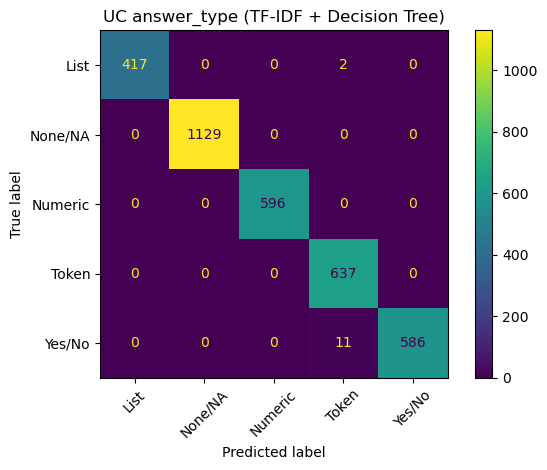

Saved outputs to: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/1_text_baselines_models/out/uc_answer_type_tfidf_dt


In [7]:
y_pred = clf.predict(X_test)

report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)
print(report)

(OUT_DIR / "classification_report.txt").write_text(report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("UC answer_type (TF-IDF + Decision Tree)")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# Save row-linked predictions (so you can trace mistakes)
preds = uc_df.iloc[idx_test].copy()
preds["y_true"] = le.inverse_transform(y_test)
preds["y_pred"] = le.inverse_transform(y_pred)
preds.to_csv(OUT_DIR / "predictions_with_rows.csv", index=False)

# Save lightweight metrics json
metrics = {
    "n_total": int(len(uc_df)),
    "n_test": int(len(idx_test)),
    "model": "tfidf + decision_tree(max_depth=5)",
    "task": "UC answer_type",
}
with open(OUT_DIR / "run_meta.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved outputs to:", OUT_DIR)
